In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("D:\Customer-Churn\Dataset/churn_dataset_cleaned.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\rohit\AppData\Local\Temp\ipykernel_16836\593763717.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Customer-Churn\Dataset/churn_dataset_cleaned.csv")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Univariate Analysis

#### Churn Distribution

In [5]:
# Set the visual style for all plots
sns.set_theme(style="whitegrid")

C:\Users\rohit\AppData\Local\Temp\ipykernel_16836\28873782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


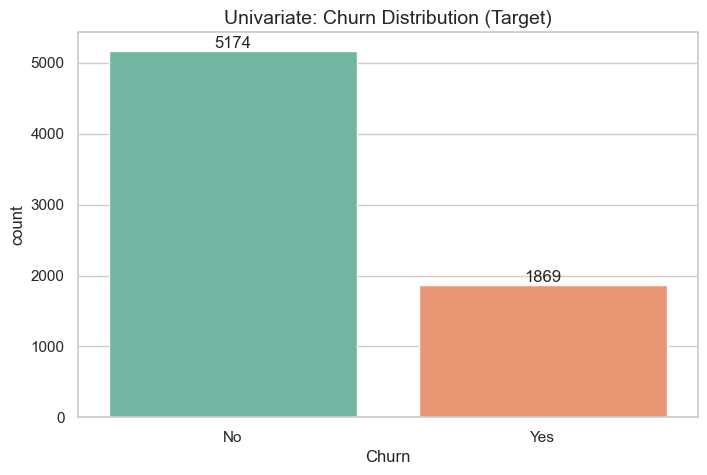

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Univariate: Churn Distribution (Target)', fontsize=14)

# Add count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

##### Observation: Churn Distribution
* **Finding:** Out of 7,043 total customers, approximately 73.5% (5,174) did not churn, while 26.5% (1,869) churned last month.
* **Business Insight:** The dataset has a mild class imbalance, with churners making up roughly a quarter of the base. This is typical in the telecommunications domain. We must keep this imbalance in mind during the modeling phase, as relying purely on basic "Accuracy" might overstate the model's performance on the minority (churned) class.

----------
----------

#### Contract type distribution

C:\Users\rohit\AppData\Local\Temp\ipykernel_16836\441911387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Contract', data=df, palette='Set3')


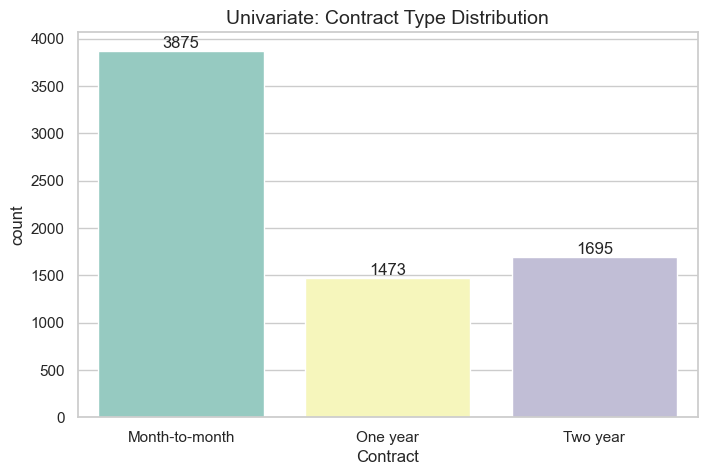

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', data=df, palette='Set3')
plt.title('Univariate: Contract Type Distribution', fontsize=14)

# Add count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

##### Observation: Contract Type Distribution
* **Finding:** Over half of the customer base (~55%, or 3,875 customers) is subscribed to a "Month-to-month" contract. The remaining customers are split between "Two year" (~24%) and "One year" (~21%) contracts.
* **Business Insight:** The company is heavily reliant on short-term, uncommitted customers. Since month-to-month users have no long-term loyalty obligations or penalty fees for leaving, the company faces a constant, high-risk monthly threat of losing a massive chunk of its user base.

### Tenure Distribution

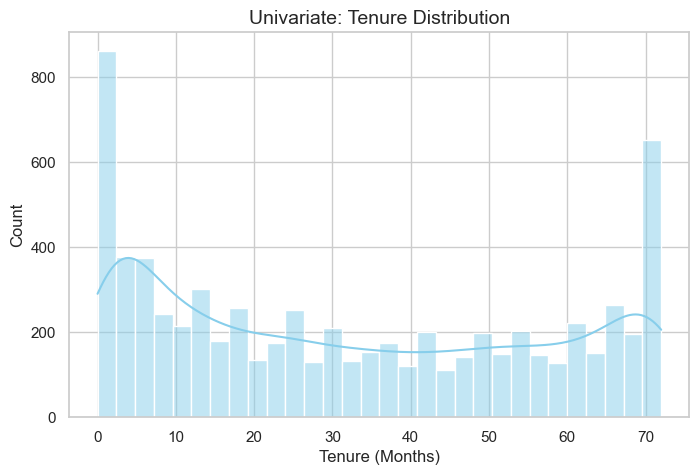

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['tenure'], bins=30, kde=True, color='skyblue')
plt.title('Univariate: Tenure Distribution', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()

##### Observation: Tenure Distribution
* **Finding:** The distribution of tenure is highly bimodal, meaning it has two extreme peaks. There is a massive spike at the `0 to 5` months range, and another massive spike at the `70 to 72` months range. 
* **Business Insight:** The company is successful at attracting brand-new customers (the early peak) and has a very solid base of fiercely loyal, long-term users (the 6-year peak). However, the "middle" (customers with 1-4 years of tenure) is comparatively hollow, suggesting many customers drop off before reaching long-term status.

#### Monthly Charges Distribution

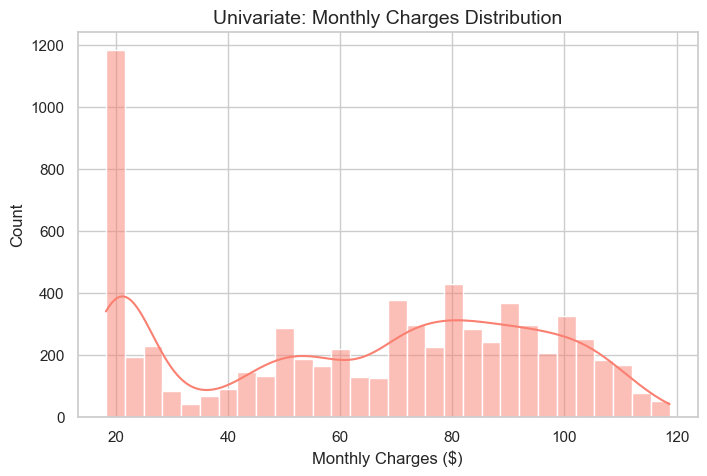

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='salmon')
plt.title('Univariate: Monthly Charges Distribution', fontsize=14)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Count')
plt.show()

##### Observation: Monthly Charges Distribution
* **Finding:** There is a massive spike at the lower end of the pricing spectrum (around $20/month). The rest of the distribution is relatively uniform, spread between $40 and $110.
* **Business Insight:** A very significant portion of the customer base subscribes to the cheapest, bare-bones plans available (likely just basic phone service without internet or add-ons). The uniformly distributed higher-paying customers represent users with varying, customized bundles of internet and premium tech services.

-----------
-----------

#### Categorical to Categorical Analysis (Contract vs Churn)

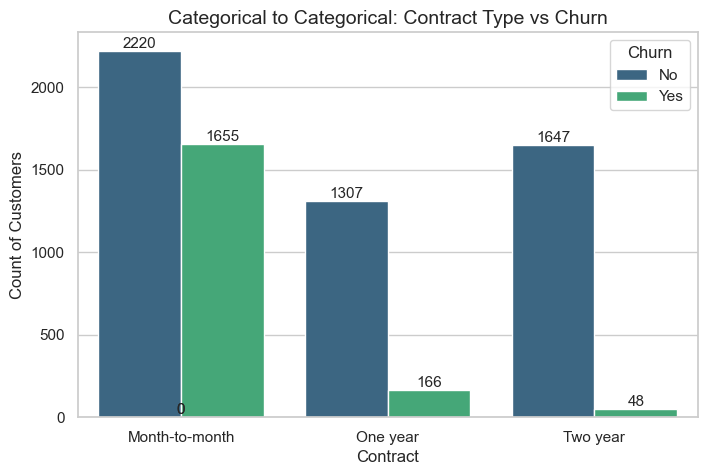

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Categorical to Categorical: Contract Type vs Churn', fontsize=14)
plt.ylabel('Count of Customers')

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)
plt.show()

##### Observation: Categorical to Categorical (Contract vs Churn)
* **Finding:** Out of the 3,875 customers on a Month-to-Month contract, 1,655 churned (an alarming ~42.7% churn rate). In stark contrast, only 166 out of 1,473 customers on a One-year contract churned (~11%), and an almost negligible 48 out of 1,695 Two-year contract customers churned (~2.8%).
* **Business Insight:** The "Contract Trap" is the single biggest categorical driver of customer attrition. Month-to-month contracts offer no friction for leaving, making these customers highly volatile. The company's highest priority should be migrating month-to-month users into annual commitments.

### 2. Categorical to Numerical Analysis (Churn vs Tenure)

C:\Users\rohit\AppData\Local\Temp\ipykernel_16836\3700583925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


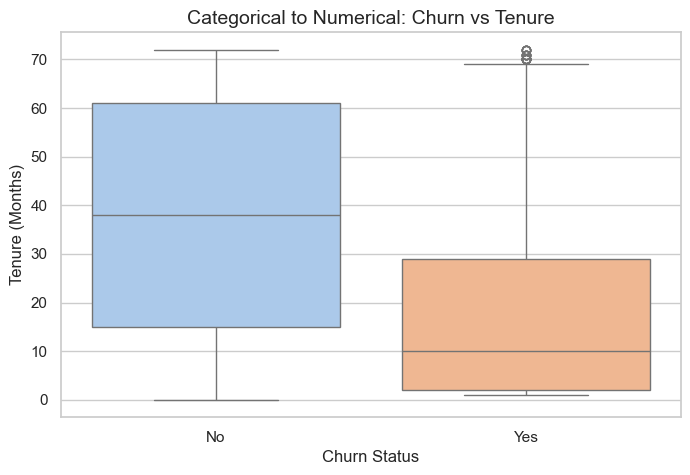

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Categorical to Numerical: Churn vs Tenure', fontsize=14)
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

##### Observation: Categorical to Numerical (Churn vs Tenure)
* **Finding:** The boxplot clearly illustrates that customers who churn (Yes) have a significantly lower median tenure (around 10 months) compared to customers who stay (No), whose median tenure sits around 38 months. Furthermore, 75% (the top of the box) of all churned customers leave before hitting the 30-month mark.
* **Business Insight:** Customer churn is an "early lifecycle" problem. The first year is highly critical. If a customer can be retained past their first 12–24 months, their likelihood of leaving plummets drastically. A robust onboarding and early-lifecycle retention strategy is strictly necessary.

### Numerical to Numerical Analysis (Tenure vs TotalCharges)

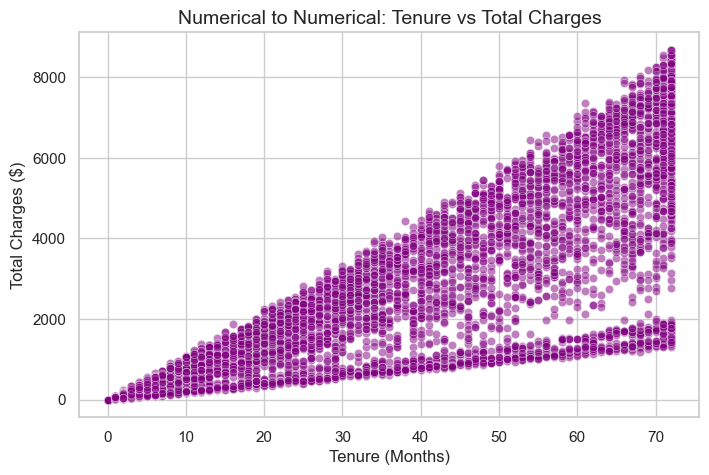

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='tenure', y='TotalCharges', data=df, alpha=0.5, color='purple')
plt.title('Numerical to Numerical: Tenure vs Total Charges', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.show()

##### Observation: Numerical to Numerical (Tenure vs Total Charges)
* **Finding:** The scatter plot reveals a strong, positive, fan-shaped correlation between Tenure and Total Charges. The longer a customer stays, the higher their total accumulated charges become. However, the "fan" shape indicates variance in Monthly Charges (some loyal customers are on cheap plans, keeping their total low, while others are on expensive bundles, pushing their total much higher).
* **Business Insight:** While obvious mathematically, this visualizes the pure monetary value of retention (Customer Lifetime Value). A single customer retained for 70 months can generate upwards of $8,000 in revenue, whereas a customer churning at month 10 yields only a fraction of that. Retention is undeniably the most profitable strategy.